# B6 (partie 2) — Auto-encodeur PyTorch GPU, noyaux de convolution 5×5 (catégorie `wood`)

> **Variante « pour le fun »** : noyaux de convolution portés à `5×5` au lieu de `3×3`
> (résolution `256×256`, hyperparamètres et device inchangés), pour observer l'effet d'un champ
> réceptif plus large sur le temps d'entraînement GPU et sur la détection. Comparé au run GPU
> `256×256` (noyau `3×3`) de [`02c-autoencoder-pytorch-gpu.ipynb`](02c-autoencoder-pytorch-gpu.ipynb)
> dans [`02f-comparaison-noyaux-convolution.ipynb`](02f-comparaison-noyaux-convolution.ipynb).

## Objectif concret

Entraîner le même auto-encodeur convolutif que `02c`, avec la seule différence que chaque convolution
(encodeur et décodeur) utilise un noyau `5×5` au lieu de `3×3`, calibrer un seuil d'anomalie sur la
validation, puis évaluer la détection sur le test (saines + défauts) — sur **GPU (ROCm)**.

Ce notebook réutilise sans les ré-expliquer les notions de la partie 1 (préparation des données,
augmentation) — voir
[`01-preparation-donnees-augmentation-wood.ipynb`](01-preparation-donnees-augmentation-wood.ipynb).

## Prérequis

- **Noyau Jupyter** : sélectionner **`Python 3.12 (indusense, PyTorch ROCm)`**
  (`indusense-py312-rocm`), pas le noyau `python3` par défaut.
- Ouvrir depuis la racine du projet `indusense`.
- Un GPU AMD compatible ROCm 7.2.1 doit être détecté (`torch.cuda.is_available()`).

## Architecture

Auto-encodeur convolutif symétrique à 3 niveaux, entrée/sortie `256×256×3` :

| Bloc | Couches | Canaux |
|---|---|---|
| Encodeur | `Conv 5×5, stride 2` ×3 (+ ReLU) | `3 → 64 → 128 → 256` |
| Goulot d'étranglement | — | `32×32×256` |
| Décodeur | `ConvTranspose 5×5, stride 2` ×3 (+ ReLU, puis Sigmoid en sortie) | `256 → 128 → 64 → 3` |

Le padding (`2`, au lieu de `1` pour un noyau `3×3`) et l'`output_padding` (`1`, inchangé) sont calculés
dans `indusense.vision.autoencoder_torch.ConvAutoencoder` pour que chaque niveau divise ou multiplie
toujours exactement par 2 la résolution spatiale, quel que soit le noyau — le goulot d'étranglement
reste donc `32×32×256`, strictement comparable à `02c`. Seul le nombre de **paramètres entraînables**
change : un noyau `5×5` contient `(5×5)/(3×3) ≈ 2,8` fois plus de poids par canal qu'un noyau `3×3`, à
même nombre de canaux.

In [1]:
from pathlib import Path
import time

import numpy as np
import torch

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)

DEVICE = "cuda"
assert torch.cuda.is_available(), "GPU ROCm non détecté par PyTorch."
device = torch.device(DEVICE)
print(f'PyTorch {torch.__version__}, device={device} ({torch.cuda.get_device_name(0)})')

from indusense.vision.dataset import (
    list_defect_categories, list_image_paths, load_image_batch,
    resolve_category_root, split_train_validation,
)
from indusense.vision.augment import augment_batch, build_augmentation_pipeline
from indusense.vision.autoencoder_torch import ConvAutoencoder, count_trainable_parameters, images_to_tensor, tensor_to_images
from indusense.vision.anomaly import TrainingRun, choose_threshold, evaluate_at_threshold, ranking_metrics, reconstruction_error

CATEGORY = 'wood'
IMAGE_SIZE = 256
KERNEL_SIZE = 5
BASE_CHANNELS = 64
BATCH_SIZE = 32
EPOCHS = 60
VALIDATION_FRACTION = 0.15
SEED = 42

category_root = resolve_category_root(CATEGORY)
defect_categories = list_defect_categories(category_root)
train_good_paths = list_image_paths(category_root, 'train', 'good')
split = split_train_validation(train_good_paths, validation_fraction=VALIDATION_FRACTION, seed=SEED)

test_good_paths = list_image_paths(category_root, 'test', 'good')
test_defect_paths = {d: list_image_paths(category_root, 'test', d) for d in defect_categories}

print(f'Train (saines, augmentées à chaque époque) : {len(split.train_paths)}')
print(f'Validation (saines, calibration du seuil) : {len(split.validation_paths)}')
print(f'Test sain : {len(test_good_paths)} ; test défauts : {sum(len(p) for p in test_defect_paths.values())}')

PyTorch 2.9.1+rocm7.2.1, device=cuda (AMD Radeon RX 9070 XT)


Train (saines, augmentées à chaque époque) : 210
Validation (saines, calibration du seuil) : 37
Test sain : 19 ; test défauts : 60


## Charger les images et construire le pipeline d'augmentation

Identique à `02c` : chargement unique en mémoire, augmentation régénérée à chaque époque, validation
et test jamais augmentés.

In [2]:
train_raw_images = load_image_batch(split.train_paths, IMAGE_SIZE)
validation_images = load_image_batch(split.validation_paths, IMAGE_SIZE)
test_good_images = load_image_batch(test_good_paths, IMAGE_SIZE)
test_defect_images = {d: load_image_batch(paths, IMAGE_SIZE) for d, paths in test_defect_paths.items()}

augmentation_pipeline = build_augmentation_pipeline(seed=SEED)

print(f'train_raw_images: {train_raw_images.shape}')
print(f'validation_images: {validation_images.shape}')
print(f'test_good_images: {test_good_images.shape}')
for defect, images in test_defect_images.items():
    print(f'test_defect_images[{defect}]: {images.shape}')

train_raw_images: (210, 256, 256, 3)
validation_images: (37, 256, 256, 3)
test_good_images: (19, 256, 256, 3)
test_defect_images[color]: (8, 256, 256, 3)
test_defect_images[combined]: (11, 256, 256, 3)
test_defect_images[hole]: (10, 256, 256, 3)
test_defect_images[liquid]: (10, 256, 256, 3)
test_defect_images[scratch]: (21, 256, 256, 3)


In [3]:
torch.manual_seed(SEED)
model = ConvAutoencoder(base_channels=BASE_CHANNELS, kernel_size=KERNEL_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

trainable_parameters = count_trainable_parameters(model)
print(model)
print(f'\nParamètres entraînables : {trainable_parameters:,}'.replace(',', ' '))

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): ReLU(inplace=True)
    (4): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 3, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (5): Sigmoid()
  )
)

Paramètres entraînables : 2 058 243


## Lecture du résultat précédent : le modèle est-il conforme ?

Le modèle compte **2 058 243** paramètres entraînables, contre **741 379** pour le noyau `3×3` de `02c` — un facteur **2,78x**, cohérent avec le ratio théorique des surfaces de noyau (`5×5` / `3×3` = 25/9 ≈ 2,78) : à nombre de canaux égal, chaque filtre convolutif contient simplement plus de poids, le goulot d'étranglement (`32×32×256`) restant identique.

## Entraîner l'auto-encodeur (identique à `02c`)

Même boucle d'entraînement, mêmes hyperparamètres, même seed.

In [4]:
def run_epoch(raw_images, model, optimizer, loss_fn, pipeline, device, batch_size):
    augmented = np.clip(augment_batch(raw_images, pipeline), 0.0, 1.0)
    batch = images_to_tensor(augmented).to(device)
    permutation = torch.randperm(batch.shape[0])
    running_loss = 0.0
    model.train()
    for start in range(0, batch.shape[0], batch_size):
        indices = permutation[start:start + batch_size]
        images = batch[indices]
        optimizer.zero_grad()
        reconstruction = model(images)
        loss = loss_fn(reconstruction, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.shape[0]
    return running_loss / batch.shape[0]


loss_history = []

first_epoch_started = time.perf_counter()
loss_history.append(run_epoch(train_raw_images, model, optimizer, loss_fn, augmentation_pipeline, device, BATCH_SIZE))
if DEVICE == "cuda":
    torch.cuda.synchronize()
first_epoch_seconds = time.perf_counter() - first_epoch_started

training_started = time.perf_counter()
for epoch in range(1, EPOCHS):
    epoch_loss = run_epoch(train_raw_images, model, optimizer, loss_fn, augmentation_pipeline, device, BATCH_SIZE)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
        print(f'Époque {epoch + 1:>3}/{EPOCHS} — perte MSE (train) = {epoch_loss:.5f}')
if DEVICE == "cuda":
    torch.cuda.synchronize()
train_seconds = time.perf_counter() - training_started + first_epoch_seconds
steady_state_seconds_per_epoch = (train_seconds - first_epoch_seconds) / (EPOCHS - 1)

print(f'\nPremière époque : {first_epoch_seconds:.3f} s')
print(f'Temps total ({EPOCHS} époques) : {train_seconds:.3f} s')
print(f"Vitesse de croisière (hors 1ère époque) : {steady_state_seconds_per_epoch * 1000:.1f} ms/époque")

Époque  10/60 — perte MSE (train) = 0.00793


Époque  20/60 — perte MSE (train) = 0.00234


Époque  30/60 — perte MSE (train) = 0.00120


Époque  40/60 — perte MSE (train) = 0.00112


Époque  50/60 — perte MSE (train) = 0.00079


Époque  60/60 — perte MSE (train) = 0.00090

Première époque : 1.848 s
Temps total (60 époques) : 70.978 s
Vitesse de croisière (hors 1ère époque) : 1171.7 ms/époque


## Lecture du résultat précédent : l'entraînement a-t-il convergé ?

La perte MSE (train, augmenté) descend jusqu'à **0,00090** en fin d'entraînement — nettement **au-dessus** des **0,00033** obtenus par le noyau `3×3` en `02c`, à budget d'époques identique (60). Avec 2,78x plus de paramètres à optimiser mais le même nombre d'époques et le même taux d'apprentissage, le modèle `5×5` n'a pas eu le temps de converger aussi finement : plus de capacité ne garantit pas une perte plus basse à budget d'entraînement fixé.

**Temps** : le noyau `5×5` coûte plus cher par époque en régime de croisière — **1171,7 ms** contre **786,4 ms** ([`02c`](02c-autoencoder-pytorch-gpu.ipynb)), soit **1,49x** plus lent — un facteur inférieur au ratio théorique de calcul (2,78x, proportionnel à la surface du noyau), signe que l'entraînement n'est pas purement limité par le calcul des convolutions à cette échelle (surcoûts fixes, lancement des noyaux GPU, etc.). La **première époque** suit un facteur proche : **1,848 s** contre **1,378 s**, soit **1,34x** — cohérent avec le régime de croisière, sans surcoût particulier ici (voir encadré ci-dessous : ce n'est vrai qu'une fois la forme `5×5` déjà connue de MIOpen). Sur l'entraînement complet, le temps total passe de **47,78 s** à **70,98 s**.

> **Point de méthode : le coût d'auto-tuning MIOpen ne se reproduit pas à chaque exécution.** Lors de la toute première fois où ce notebook a tourné sur cette machine, la première époque avait pris **46,08 s** (facteur **33,6x** par rapport au noyau `3×3`) : MIOpen avait dû rechercher le meilleur algorithme de convolution pour un noyau `5×5`, jamais rencontré jusque-là. Ce résultat a été mis en cache de façon **persistante sur disque** : à la ré-exécution actuelle, cette forme est déjà connue, et la première époque redevient proportionnelle au régime de croisière, comme n'importe quelle autre époque. Le même phénomène a été observé pour le passage à `512×512` dans [`02c-autoencoder-pytorch-gpu-512px.ipynb`](02c-autoencoder-pytorch-gpu-512px.ipynb) : c'est un coût **ponctuel, par forme de tenseur et par machine**, pas une propriété stable du noyau `5×5`.

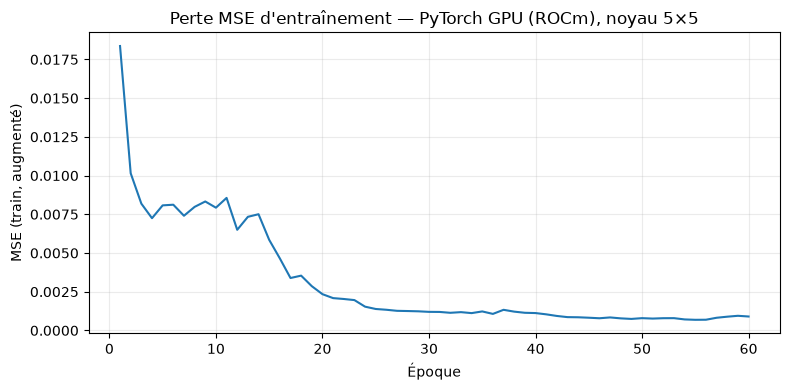

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), loss_history)
ax.set(title="Perte MSE d'entraînement — PyTorch GPU (ROCm), noyau 5×5", xlabel='Époque', ylabel='MSE (train, augmenté)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Calibrer le seuil et évaluer la détection d'anomalie

Le modèle passe en mode évaluation (`model.eval()`). L'erreur de reconstruction moyenne par image sert
de **score d'anomalie**. Le seuil est calibré sur la validation (saine uniquement) :
`moyenne + 3 écarts-types`. Le test combine les images saines (`label = 0`) et toutes les catégories de
défauts (`label = 1`).

In [6]:
@torch.no_grad()
def reconstruct(images_hwc, model, device, batch_size=32):
    model.eval()
    tensor = images_to_tensor(images_hwc)
    outputs = []
    for start in range(0, tensor.shape[0], batch_size):
        batch = tensor[start:start + batch_size].to(device)
        outputs.append(tensor_to_images(model(batch)))
    return np.concatenate(outputs, axis=0)


validation_reconstruction = reconstruct(validation_images, model, device)
validation_errors = reconstruction_error(validation_images, validation_reconstruction)
threshold = choose_threshold(validation_errors, n_std=3.0)

test_images_by_group = {'good': test_good_images, **test_defect_images}
test_errors_by_group = {}
for group_name, images in test_images_by_group.items():
    reconstruction = reconstruct(images, model, device)
    test_errors_by_group[group_name] = reconstruction_error(images, reconstruction)

test_labels = np.concatenate([
    np.zeros(len(test_errors_by_group['good']), dtype=int),
    *[np.ones(len(test_errors_by_group[d]), dtype=int) for d in defect_categories],
])
test_scores = np.concatenate([test_errors_by_group['good']] + [test_errors_by_group[d] for d in defect_categories])

ranking = ranking_metrics(test_labels, test_scores)
threshold_metrics = evaluate_at_threshold(test_labels, test_scores, threshold)
mean_error_by_defect = {group: float(errors.mean()) for group, errors in test_errors_by_group.items()}

from tabulate import tabulate
print(f'Seuil (validation, moyenne + 3 écarts-types) : {threshold:.6f}')
print(f"ROC-AUC test : {ranking['roc_auc']:.4f} ; PR-AUC test : {ranking['pr_auc']:.4f}\n")
print(tabulate(
    [[group, f'{err:.6f}'] for group, err in mean_error_by_defect.items()],
    headers=['Groupe', 'Erreur de reconstruction moyenne'], tablefmt='github',
))
print()
print(tabulate(
    [[threshold_metrics.precision, threshold_metrics.recall, threshold_metrics.f1,
      threshold_metrics.true_positive, threshold_metrics.true_negative,
      threshold_metrics.false_positive, threshold_metrics.false_negative]],
    headers=['Précision', 'Rappel', 'F1', 'VP', 'VN', 'FP', 'FN'], tablefmt='github',
))

Seuil (validation, moyenne + 3 écarts-types) : 0.002126
ROC-AUC test : 0.9535 ; PR-AUC test : 0.9858

| Groupe   |   Erreur de reconstruction moyenne |
|----------|------------------------------------|
| good     |                           0.000565 |
| color    |                           0.00105  |
| combined |                           0.001171 |
| hole     |                           0.001253 |
| liquid   |                           0.00092  |
| scratch  |                           0.001289 |

|   Précision |    Rappel |        F1 |   VP |   VN |   FP |   FN |
|-------------|-----------|-----------|------|------|------|------|
|           1 | 0.0333333 | 0.0645161 |    2 |   19 |    0 |   58 |


## Lecture du résultat précédent : le seuil détecte-t-il les défauts ?

Le classement reste très bon mais légèrement **inférieur** à celui du noyau `3×3` : ROC-AUC = **0,9535** (contre 0,9632), PR-AUC = **0,9858** (contre 0,9884). Au seuil `moyenne + 3 écarts-types` calibré sur la validation, la détection se dégrade nettement : **2** défauts détectés sur **60** (rappel = **0,033**) contre **7** pour le noyau `3×3` (rappel = 0,117) — sans aucune fausse alerte dans les deux cas (précision = 1,00).

Cette dégradation ne vient pas d'un problème de séparation saine/défaut : les ratios erreur défaut / erreur saine sont quasiment identiques entre les deux noyaux (ex. `scratch`/`good` = 2,37 en `3×3` contre 2,28 en `5×5`) — la capacité du modèle à distinguer visuellement les défauts des saines est globalement préservée. Ce qui change, c'est la **dispersion relative** des erreurs de validation : l'écart-type relatif à la moyenne (`std/mean`) vaut **0,411** pour le noyau `5×5` contre **0,357** pour le noyau `3×3` — une validation saine proportionnellement plus dispersée pousse le seuil `moyenne + 3σ` plus loin dans la distribution des erreurs, ce qui manque davantage de défauts à seuil identique. Le classement (ROC-AUC/PR-AUC) le confirme : il ne dépend d'aucun seuil et reste comparable ; c'est la **politique de seuil**, appliquée à une distribution de validation plus étalée, qui pénalise le rappel ici — la même leçon que `02e`, sur un autre paramètre architectural.

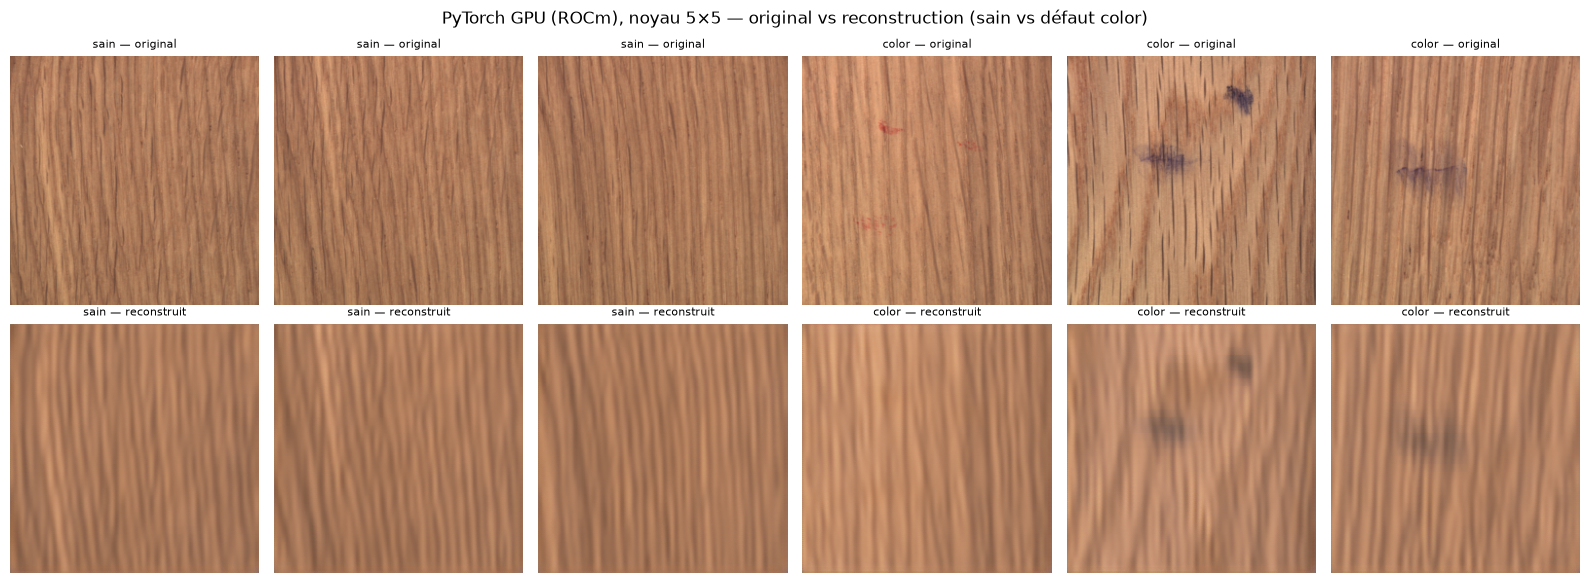

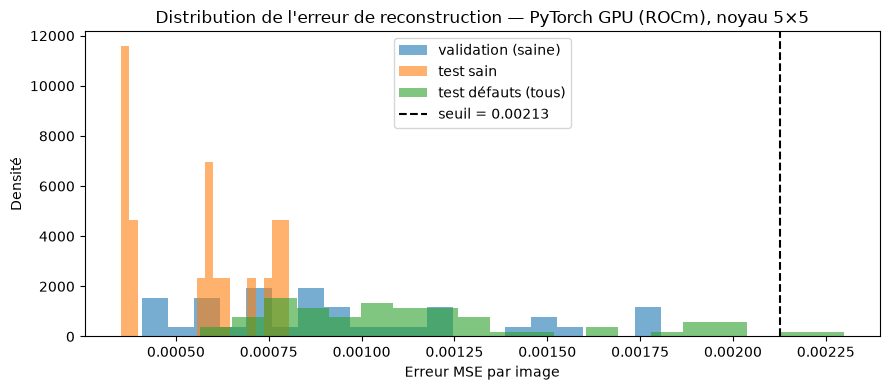

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
sample_good = test_good_images[:3]
sample_good_recon = reconstruct(sample_good, model, device)
sample_defect_name = defect_categories[0]
sample_defect = test_images_by_group[sample_defect_name][:3]
sample_defect_recon = reconstruct(sample_defect, model, device)

for col in range(3):
    axes[0, col].imshow(np.clip(sample_good[col], 0, 1)); axes[0, col].set_title('sain — original', fontsize=8); axes[0, col].axis('off')
    axes[1, col].imshow(np.clip(sample_good_recon[col], 0, 1)); axes[1, col].set_title('sain — reconstruit', fontsize=8); axes[1, col].axis('off')
for col in range(3):
    axes[0, col + 3].imshow(np.clip(sample_defect[col], 0, 1)); axes[0, col + 3].set_title(f'{sample_defect_name} — original', fontsize=8); axes[0, col + 3].axis('off')
    axes[1, col + 3].imshow(np.clip(sample_defect_recon[col], 0, 1)); axes[1, col + 3].set_title(f'{sample_defect_name} — reconstruit', fontsize=8); axes[1, col + 3].axis('off')
fig.suptitle(f'PyTorch GPU (ROCm), noyau 5×5 — original vs reconstruction (sain vs défaut {sample_defect_name})')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(validation_errors, bins=20, alpha=0.6, label='validation (saine)', density=True)
ax.hist(test_errors_by_group['good'], bins=20, alpha=0.6, label='test sain', density=True)
all_defect_errors = np.concatenate([test_errors_by_group[d] for d in defect_categories])
ax.hist(all_defect_errors, bins=20, alpha=0.6, label='test défauts (tous)', density=True)
ax.axvline(threshold, color='black', linestyle='--', label=f'seuil = {threshold:.5f}')
ax.set(title="Distribution de l'erreur de reconstruction — PyTorch GPU (ROCm), noyau 5×5", xlabel='Erreur MSE par image', ylabel='Densité')
ax.legend()
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : que montrent les reconstructions ?

Comme pour le noyau `3×3`, les images saines sont reconstruites de façon lisse ; le grain fin du bois reste peu restitué (goulot d'étranglement identique `32×32×256`). Le champ réceptif plus large du noyau `5×5` (chaque unité de sortie « voit » une zone d'entrée plus grande à chaque niveau) n'améliore pas visiblement la restitution des textures fines et n'accentue pas la distinction avec les défauts — cohérent avec l'observation ci-dessus : les ratios erreur défaut / erreur saine sont quasi inchangés entre les deux noyaux, le champ réceptif plus large ne change pas fondamentalement ce que le modèle apprend à reconstruire ici.

**Bilan de l'expérience « pour le fun »** : une fois la forme `5×5` déjà connue de MIOpen (cache disque chaud, cf. encadré ci-dessus), passer d'un noyau `3×3` à `5×5` multiplie les paramètres par **2,78x** et le temps de croisière par **1,49x** (un facteur inférieur au ratio théorique de calcul) — sans gain de qualité de détection : le classement est légèrement inférieur et le rappel au seuil `moyenne + 3σ` chute (dispersion de validation plus grande, voir plus bas). Pour cette catégorie et cette architecture, `3×3` reste le meilleur compromis temps/qualité/rappel.

## Visualiser les détections au seuil retenu (vrais positifs, faux négatifs)

Conseil de la formatrice : au-delà des exemples génériques sain/défaut ci-dessus (choisis sans lien
avec le seuil), il est plus parlant d'inspecter concrètement **les images que le modèle classe
réellement** au seuil calibré (`moyenne + 3 écarts-types`) :

- **Vrais positifs (VP)** : images de défaut correctement signalées (`label = 1` et score ≥ seuil).
- **Faux négatifs (FN)** : images de défaut classées à tort comme **saines** (`label = 1` et
  score < seuil) — ce sont les défauts qui passeraient inaperçus en production, l'angle mort direct
  du faible rappel mesuré ci-dessus.

Les VP sont triés par score décroissant (détections les plus franches d'abord) ; les FN aussi, par
score décroissant parmi les ratés (les plus proches du seuil — les « presque détectés » — d'abord).

Défauts détectés (vrais positifs) : 2 / 60
Défauts classés sains (faux négatifs) : 58 / 60


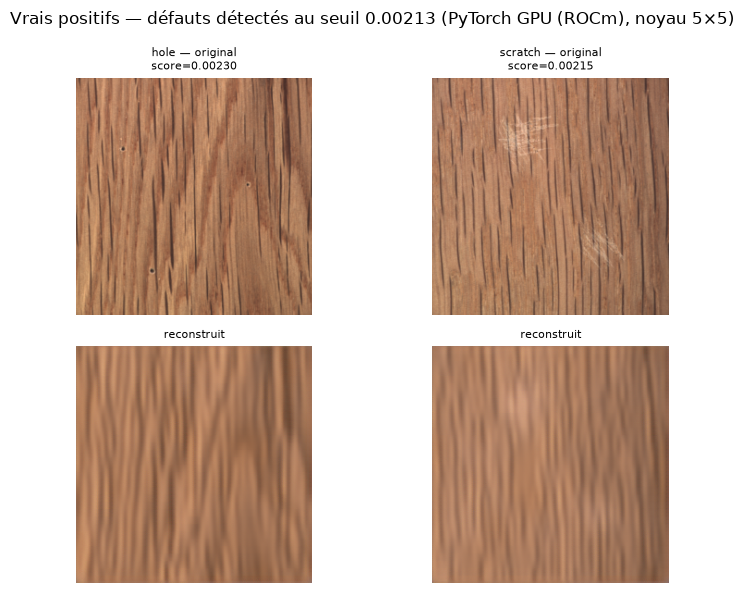

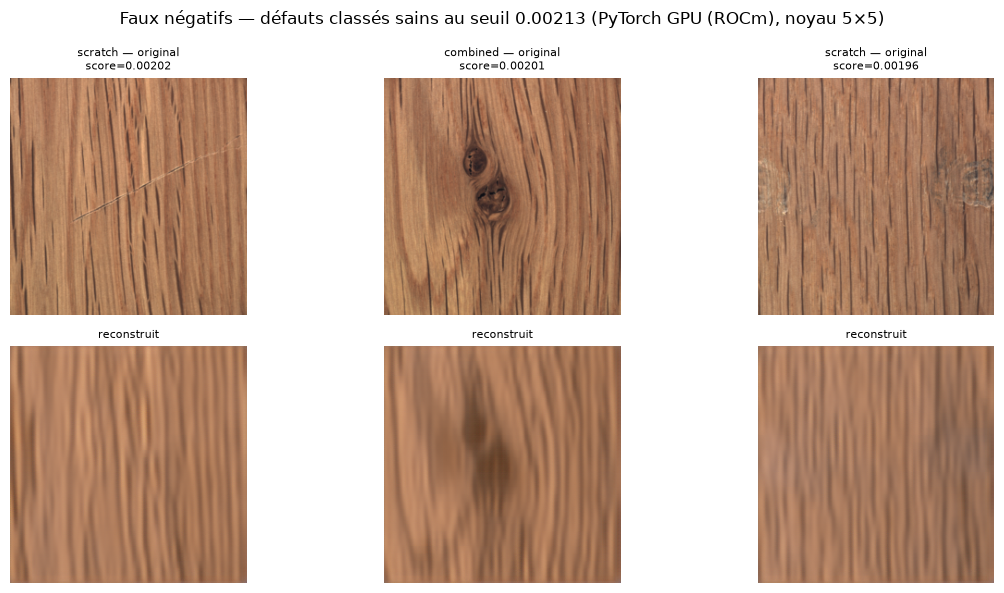

In [8]:
predictions = (test_scores >= threshold).astype(int)
test_group_names = np.array(
    ['good'] * len(test_errors_by_group['good'])
    + [defect for defect in defect_categories for _ in range(len(test_errors_by_group[defect]))]
)
test_images_concat = np.concatenate(
    [test_images_by_group['good']] + [test_images_by_group[d] for d in defect_categories], axis=0
)

true_positive_indices = np.where((test_labels == 1) & (predictions == 1))[0]
false_negative_indices = np.where((test_labels == 1) & (predictions == 0))[0]
true_positive_indices = true_positive_indices[np.argsort(-test_scores[true_positive_indices])][:3]
false_negative_indices = false_negative_indices[np.argsort(-test_scores[false_negative_indices])][:3]

print(f'Défauts détectés (vrais positifs) : {int(((test_labels == 1) & (predictions == 1)).sum())} / {int((test_labels == 1).sum())}')
print(f'Défauts classés sains (faux négatifs) : {int(((test_labels == 1) & (predictions == 0)).sum())} / {int((test_labels == 1).sum())}')


def plot_detections(indices, title):
    if len(indices) == 0:
        print(f'{title} : aucune image (0 cas au seuil retenu).')
        return
    imgs = test_images_concat[indices]
    reconstructed = reconstruct(imgs, model, device)
    fig, axes = plt.subplots(2, len(indices), figsize=(4 * len(indices), 6), squeeze=False)
    for col, idx in enumerate(indices):
        axes[0, col].imshow(np.clip(imgs[col], 0, 1))
        axes[0, col].set_title(f'{test_group_names[idx]} — original\nscore={test_scores[idx]:.5f}', fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].imshow(np.clip(reconstructed[col], 0, 1))
        axes[1, col].set_title('reconstruit', fontsize=8)
        axes[1, col].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_detections(true_positive_indices, f'Vrais positifs — défauts détectés au seuil {threshold:.5f} (PyTorch GPU (ROCm), noyau 5×5)')
plot_detections(false_negative_indices, f'Faux négatifs — défauts classés sains au seuil {threshold:.5f} (PyTorch GPU (ROCm), noyau 5×5)')

## Lecture du résultat précédent : que montrent ces détections ?

Seulement **2** défauts sur 60 sont détectés (vrais positifs) et **58** sont classés à tort comme sains (faux négatifs) — le plus faible rappel des cinq exécutions de cette famille de notebooks (0,03), cohérent avec le seuil `moyenne + 3σ` plus élevé et une validation plus dispersée (voir plus bas). Les 2 vrais positifs affichés sont les seuls défauts qui dépassent le seuil, avec un écart visuel net entre original et reconstruction.

Les faux négatifs affichés (les plus proches du seuil parmi les 58 ratés) montrent des reconstructions presque aussi fidèles que celles d'images saines : avec un seuil aussi élevé (0,002126, plus du double de celui du noyau `3×3`), la quasi-totalité des défauts, même francs, ne suffit plus à franchir la barre — la conséquence directe, illustrée image par image, de la dispersion de validation plus grande discutée ci-dessous.

In [9]:
run = TrainingRun(
    framework='pytorch',
    device=DEVICE,
    category=CATEGORY,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    trainable_parameters=trainable_parameters,
    first_epoch_seconds=first_epoch_seconds,
    train_seconds=train_seconds,
    seconds_per_epoch=steady_state_seconds_per_epoch,
    final_train_loss=loss_history[-1],
    validation_error_mean=float(validation_errors.mean()),
    validation_error_std=float(validation_errors.std()),
    threshold=threshold,
    roc_auc=ranking['roc_auc'],
    pr_auc=ranking['pr_auc'],
    metrics_at_threshold=threshold_metrics,
    mean_error_by_defect=mean_error_by_defect,
    kernel_size=KERNEL_SIZE,
)
run_path = PROJECT_ROOT / "outputs/deep-learning/pytorch-gpu-kernel5x5.json"
run.to_json(run_path)
print(f'Résultats sauvegardés : {run_path}')
print(f'Première époque : {first_epoch_seconds:.3f} s, croisière : {steady_state_seconds_per_epoch*1000:.1f} ms/époque, total : {train_seconds:.3f} s')

Résultats sauvegardés : D:\source\A4U\FormationIA\indusense\outputs\deep-learning\pytorch-gpu-kernel5x5.json
Première époque : 1.848 s, croisière : 1171.7 ms/époque, total : 70.978 s


## Synthèse

Entraînement PyTorch GPU (ROCm) du même auto-encodeur que `02c`, avec des noyaux de convolution `5×5` au lieu de `3×3` (padding et `output_padding` recalculés pour conserver un goulot d'étranglement identique `32×32×256`). Résultats détaillés (paramètres, temps, ROC-AUC, PR-AUC, précision/rappel) dans les cellules ci-dessus, et comparaison consolidée face au noyau `3×3` dans [`02f-comparaison-noyaux-convolution.ipynb`](02f-comparaison-noyaux-convolution.ipynb).